In [1]:
import torch
import torch.nn as nn
import cying.nn as cynn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
device = torch.device('cuda:0')

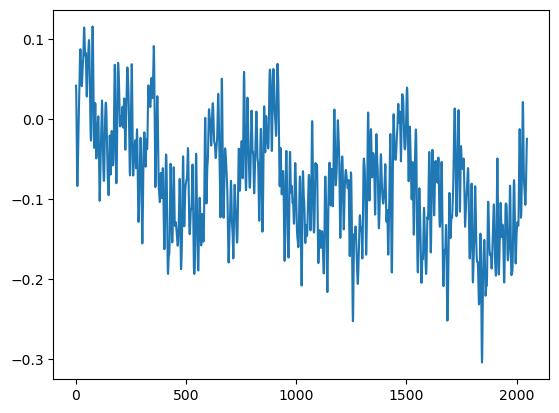

In [33]:
x = torch.randn(128)
y = torch.randn(128)
t1 = 0.
# t2 = 0.
s = []
T = 2048
for t2 in range(T):
    theta = 10000**(-torch.arange(128//2+1)/(128//2+1))
    pe_weight1 = torch.exp(1j*t1*theta)
    pe_weight2 = torch.exp(1j*t2*theta)
    x_fre1 = torch.fft.rfft(x) * pe_weight1 / 128
    x_fre2 = torch.fft.rfft(y) * pe_weight2 / 128
    s.append((x_fre1*x_fre2.conj()).sum().real*2)
s = torch.tensor(s)
s = s * torch.sigmoid(1*(s-0.5)) + s * torch.sigmoid(1*(-s-0.5))
plt.plot(range(T),s)
# plt.scatter(range(T),s)

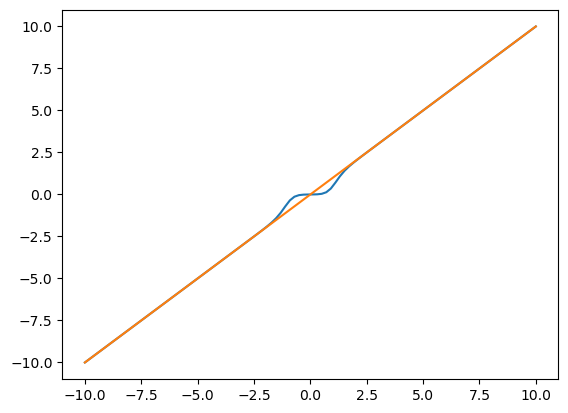

In [35]:
x = torch.linspace(-10,10,100)
y = x * torch.sigmoid(5*(x-1)) + x * torch.sigmoid(5*(-x-1))
plt.plot(x,y)
plt.plot(x,x)

In [2]:
import os
from PIL import Image
class FIVES(Dataset):
    def __init__(self, path, transform):
        super().__init__()
        self.path = path
        self.transform = transform
        self.original_path = path+'original/'
        self.ground_truth_path = path+'ground_truth/'
        self.file_list = os.listdir(self.original_path)

    def __getitem__(self, index):
        image = Image.open(self.original_path+self.file_list[index]).convert('RGB')
        label = Image.open(self.ground_truth_path+self.file_list[index]).convert('L')
        return self.transform(image), (self.transform(label)>0.5).float()
    
    def __len__(self):
        return len(self.file_list)

In [3]:
train_path = r'./cying/datasets/FIVES/train/'
valid_path = r'./cying/datasets/FIVES/valid/'
size = (512,512)
train_transform = transforms.Compose([
    transforms.Resize(size),
    transforms.ToTensor()
])
valid_transform = transforms.Compose([
    transforms.Resize(size),
    transforms.ToTensor()
])
train_dataset = FIVES(
    path=train_path,
    transform=train_transform
)
valid_dataset = FIVES(
    path=valid_path,
    transform=valid_transform
)

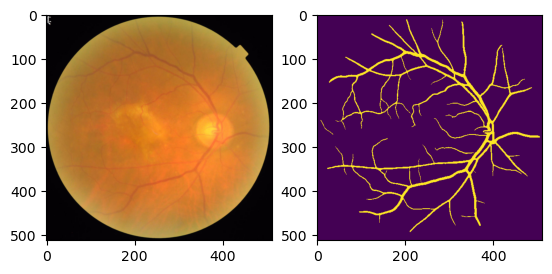

In [4]:
image, label = train_dataset[1]
plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.subplot(1,2,2)
plt.imshow(label.permute(1,2,0)>0.5)

In [5]:
from torchinfo import summary
params = [
    {
        'in_channels': 3,
        'out_channels': 7,
        'hidden_width': 128,
        'spe_opt_size': (16,16),
        'spa_opt_size': 11
    },
    *[{
        'in_channels': 7,
        'out_channels': 7,
        'hidden_width': 128,
        'spe_opt_size': (16,16),
        'spa_opt_size': 11
    }]*5,
    {
        'in_channels': 7,
        'out_channels': 1,
        'hidden_width': 128,
        'spe_opt_size': (16,16),
        'spa_opt_size': 11
    }
]
cyonet = cynn.OptModel2d(
    size=size,
    params=params
).to(device)
summary(cyonet)

Layer (type:depth-idx)                   Param #
OptModel2d                               --
├─Sequential: 1-1                        --
│    └─OptLayer2d: 2-1                   --
│    │    └─OptSpectralConv2d: 3-1       1,536
│    │    └─OptConv2d: 3-2               363
│    │    └─Sequential: 3-3              1,415
│    │    └─Conv2d: 3-4                  28
│    └─OptLayer2d: 2-2                   --
│    │    └─OptSpectralConv2d: 3-5       3,584
│    │    └─OptConv2d: 3-6               847
│    │    └─Sequential: 3-7              1,927
│    │    └─Conv2d: 3-8                  56
│    └─OptLayer2d: 2-3                   --
│    │    └─OptSpectralConv2d: 3-9       3,584
│    │    └─OptConv2d: 3-10              847
│    │    └─Sequential: 3-11             1,927
│    │    └─Conv2d: 3-12                 56
│    └─OptLayer2d: 2-4                   --
│    │    └─OptSpectralConv2d: 3-13      3,584
│    │    └─OptConv2d: 3-14              847
│    │    └─Sequential: 3-15             1,927

In [6]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred_flat = pred.view(pred.size(0), -1)
        target_flat = target.view(target.size(0), -1)
        
        intersection = (pred_flat * target_flat).sum(dim=1)
        union = pred_flat.sum(dim=1) + target_flat.sum(dim=1)
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice_score.mean()
        
        return dice_loss

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.6, smooth=1e-6):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.dice_loss = DiceLoss(smooth=smooth)
        
    def forward(self, pred, target):
        bce_loss = F.binary_cross_entropy(pred, target)
        
        combined_loss = self.bce_weight * bce_loss + (1 - self.bce_weight) * self.dice_loss(pred, target)
        
        return combined_loss

In [7]:
from tqdm import tqdm

epoch = 10**2
lr = 1e-3
batch = 1

optim = torch.optim.Adam(cyonet.parameters(),lr=lr)
loss_fun = BCEDiceLoss(0.6,1e-6)
train_loader = DataLoader(train_dataset,batch_size=batch,shuffle=True)
valid_loader = DataLoader(valid_dataset)


for i in range(epoch):
    cyonet.train()
    print('-------------------------------Epoch:',i,'---------------------------------')
    train_bar = tqdm(train_loader)
    train_loss = 0.
    for images, labels in train_bar:
        optim.zero_grad()
        preds = cyonet(images.to(device))
        loss = loss_fun(F.sigmoid(preds),labels.to(device))
        loss.backward()
        train_loss += loss.item()
        optim.step()
        train_bar.set_postfix({
            'Train loss': f'{loss.item():.5f}'
        })
    cyonet.eval()
    train_loss /= train_dataset.__len__()
    with torch.no_grad():
        valid_loss = 0.
        for images, labels in tqdm(valid_loader):
            preds = F.sigmoid(cyonet(images.to(device)))
            valid_loss += DiceLoss()(preds,labels.to(device)).item()
        valid_loss /= valid_dataset.__len__()
        print('Total train loss: ', train_loss)
        print('Total valid dice loss: ', valid_loss)
    print('-------------------------------------------------------------------------')

-------------------------------Epoch: 0 ---------------------------------


100%|██████████| 100/100 [00:17<00:00,  5.74it/s]


Total train loss:  0.4961164280176163
Total valid dice loss:  0.8378457564115525
-------------------------------------------------------------------------
-------------------------------Epoch: 1 ---------------------------------


100%|██████████| 100/100 [00:17<00:00,  5.66it/s]


Total train loss:  0.29789872154593466
Total valid dice loss:  0.33312183141708374
-------------------------------------------------------------------------
-------------------------------Epoch: 2 ---------------------------------


...

Total train loss:  0.06379400220513344
Total valid dice loss:  0.0982546216249466
-------------------------------------------------------------------------
-------------------------------Epoch: 98 ---------------------------------


100%|██████████| 100/100 [00:17<00:00,  5.69it/s]


Total train loss:  0.06337350525707007
Total valid dice loss:  0.09640128970146179
-------------------------------------------------------------------------
-------------------------------Epoch: 99 ---------------------------------


100%|██████████| 100/100 [00:17<00:00,  5.75it/s]

Total train loss:  0.06411952960118651
Total valid dice loss:  0.09888511955738068
-------------------------------------------------------------------------


In [8]:
test_path = r'./cying/datasets/FIVES/test/'
size = (512,512)
transform = transforms.Compose([
    transforms.Resize(size),
    transforms.ToTensor(),
])
test_dataset = FIVES(
    path=test_path,
    transform=transform
)

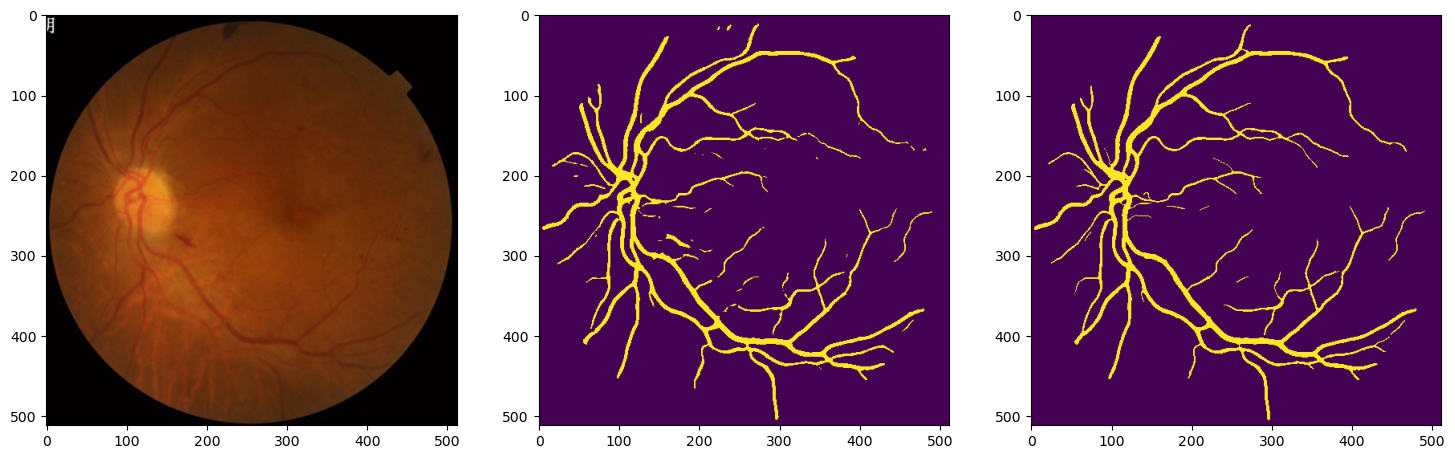

In [12]:
i = 0
with torch.no_grad():
    image, label = test_dataset[i]
    pre = torch.sigmoid(cyonet(image.unsqueeze(0).to(device))[0].cpu().detach())>0.5
plt.figure(figsize=(18,8))
plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.subplot(1,3,2)
plt.imshow(pre.permute(1,2,0))
plt.subplot(1,3,3)
plt.imshow(label.permute(1,2,0))